# Análisis del Tipo de Cambio USD/PEN

Evolución diaria del tipo de cambio en bancos peruanos (2023-2024)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PALETA = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
sns.set_palette(PALETA)

## Generación de datos realistas

In [2]:
np.random.seed(42)

bancos = ['BCP', 'BBVA', 'Scotiabank', 'Interbank', 'BanBif', 'Pichincha']
fechas = pd.bdate_range('2023-01-02', '2024-12-31')

# tendencia base USD/PEN: ~3.80 en ene-2023, baja a ~3.65 mid-2023, sube a ~3.75 fin-2024
n_dias = len(fechas)
tendencia = 3.80 + 0.05 * np.sin(np.linspace(0, 3 * np.pi, n_dias)) + np.linspace(0, -0.05, n_dias)
ruido_mercado = np.cumsum(np.random.normal(0, 0.003, n_dias))
ruido_mercado -= np.linspace(ruido_mercado[0], ruido_mercado[-1], n_dias)
tc_base = tendencia + ruido_mercado

registros = []
spreads_banco = {
    'BCP': 0.015, 'BBVA': 0.018, 'Scotiabank': 0.020,
    'Interbank': 0.016, 'BanBif': 0.025, 'Pichincha': 0.028
}

for banco in bancos:
    offset = np.random.uniform(-0.01, 0.01)
    spread = spreads_banco[banco]
    for i, fecha in enumerate(fechas):
        tc_compra = tc_base[i] + offset + np.random.normal(0, 0.005)
        tc_venta = tc_compra + spread + np.random.uniform(0, 0.008)
        registros.append({
            'fecha': fecha,
            'banco': banco,
            'tc_compra': round(tc_compra, 4),
            'tc_venta': round(tc_venta, 4)
        })

df = pd.DataFrame(registros)
df['spread'] = df['tc_venta'] - df['tc_compra']
df['mes'] = df['fecha'].dt.to_period('M')
df.shape

(3132, 6)

In [3]:
df.head(10)

,fecha,banco,tc_compra,tc_venta,spread,mes
0,2023-01-02,BCP,3.8026,3.8210,0.0184,2023-01
1,2023-01-03,BCP,3.8008,3.8198,0.0190,2023-01
2,2023-01-04,BCP,3.8062,3.8261,0.0199,2023-01
3,2023-01-05,BCP,3.8124,3.8297,0.0173,2023-01
4,2023-01-06,BCP,3.8083,3.8272,0.0189,2023-01
5,2023-01-09,BCP,3.8155,3.8347,0.0192,2023-01
6,2023-01-10,BCP,3.8189,3.8350,0.0161,2023-01
7,2023-01-11,BCP,3.8207,3.8362,0.0155,2023-01
8,2023-01-12,BCP,3.8191,3.8396,0.0205,2023-01
9,2023-01-13,BCP,3.8284,3.8495,0.0211,2023-01


In [4]:
df.describe()

,fecha,tc_compra,tc_venta,spread
count,3132,3132.000000,3132.000000,3132.000000
mean,2023-12-31 21:39:18.620689,3.779113,3.803381,0.024268
min,2023-01-02 00:00:00,3.693000,3.712800,0.015000
25%,2023-07-03 00:00:00,3.749275,3.773175,0.020200
50%,2024-01-01 12:00:00,3.786850,3.810250,0.023300
75%,2024-07-02 00:00:00,3.808700,3.833100,0.028500
max,2024-12-31 00:00:00,3.868600,3.896500,0.036000
std,NaN,0.037402,0.037945,0.005269


## Tendencia diaria del tipo de cambio (compra promedio)

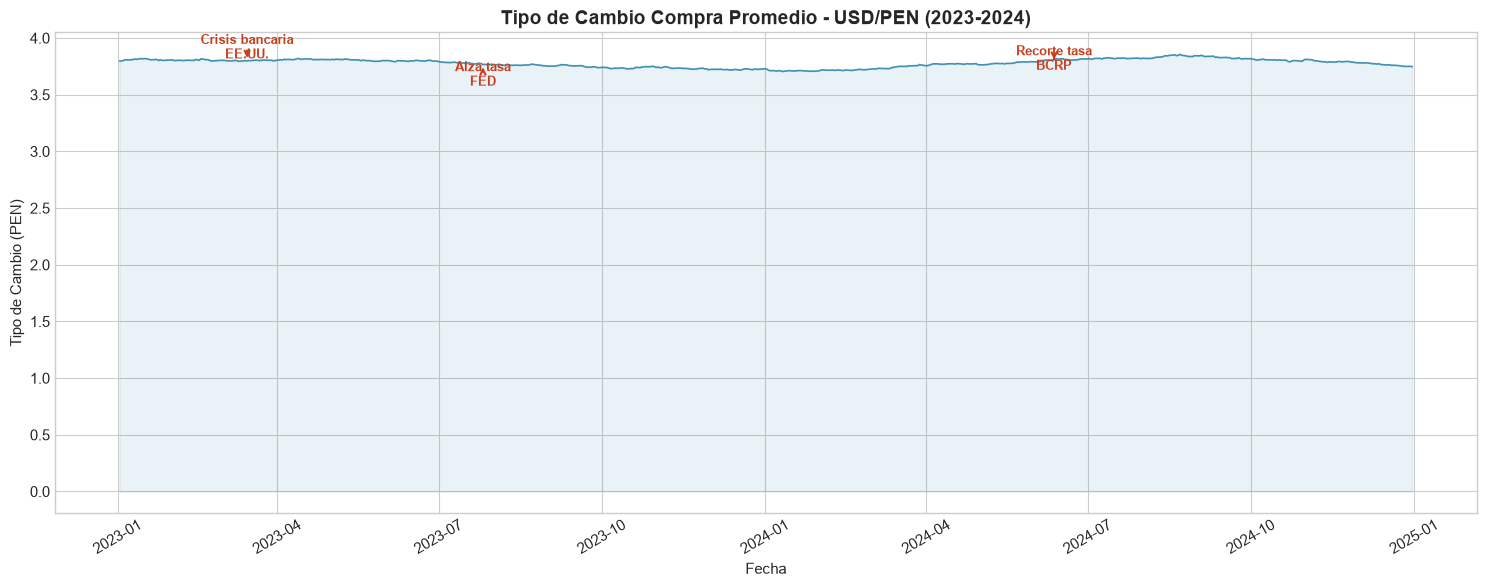

In [5]:
promedio_diario = df.groupby('fecha')['tc_compra'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_diario.index, promedio_diario.values, color='#2E86AB', linewidth=1.2, alpha=0.9)
ax.fill_between(promedio_diario.index, promedio_diario.values, alpha=0.1, color='#2E86AB')

# eventos clave
eventos = {
    '2023-03-15': ('Crisis bancaria\nEE.UU.', 3.82),
    '2023-07-26': ('Alza tasa\nFED', 3.58),
    '2024-06-12': ('Recorte tasa\nBCRP', 3.72),
}

for fecha_str, (texto, y_pos) in eventos.items():
    fecha_dt = pd.Timestamp(fecha_str)
    if fecha_dt in promedio_diario.index:
        valor = promedio_diario.loc[fecha_dt]
    else:
        idx = promedio_diario.index.get_indexer([fecha_dt], method='nearest')[0]
        valor = promedio_diario.iloc[idx]
        fecha_dt = promedio_diario.index[idx]
    ax.annotate(texto, xy=(fecha_dt, valor), xytext=(fecha_dt, y_pos),
                arrowprops=dict(arrowstyle='->', color='#C73E1D', lw=1.5),
                fontsize=9, ha='center', color='#C73E1D', fontweight='bold')

ax.set_title('Tipo de Cambio Compra Promedio - USD/PEN (2023-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Tipo de Cambio (PEN)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Distribución del spread por banco

/var/folders/tl/wg__gcjn297fhnfclpjmjygc0000gn/T/ipykernel_84662/3098275953.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='banco', y='spread', order=orden_bancos, ax=ax,


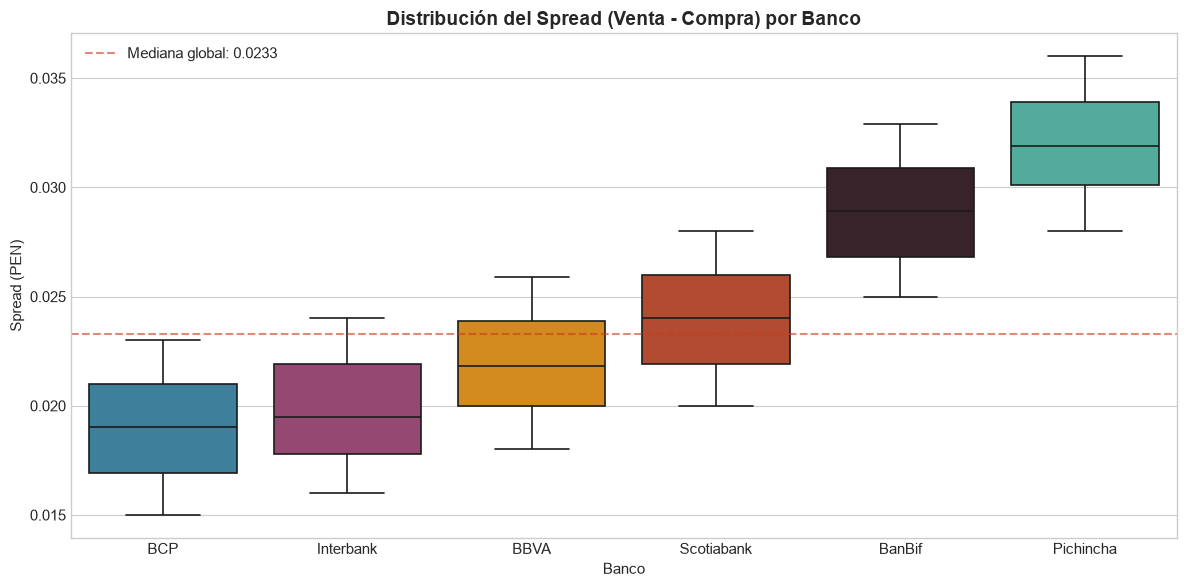

In [6]:
orden_bancos = df.groupby('banco')['spread'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='banco', y='spread', order=orden_bancos, ax=ax,
            palette=PALETA, linewidth=1.2, fliersize=2)
ax.set_title('Distribución del Spread (Venta - Compra) por Banco', fontsize=14, fontweight='bold')
ax.set_xlabel('Banco')
ax.set_ylabel('Spread (PEN)')
ax.axhline(y=df['spread'].median(), color='#C73E1D', linestyle='--', alpha=0.6, label=f'Mediana global: {df["spread"].median():.4f}')
ax.legend()
plt.tight_layout()
plt.show()

## Heatmap: tipo de cambio mensual por banco

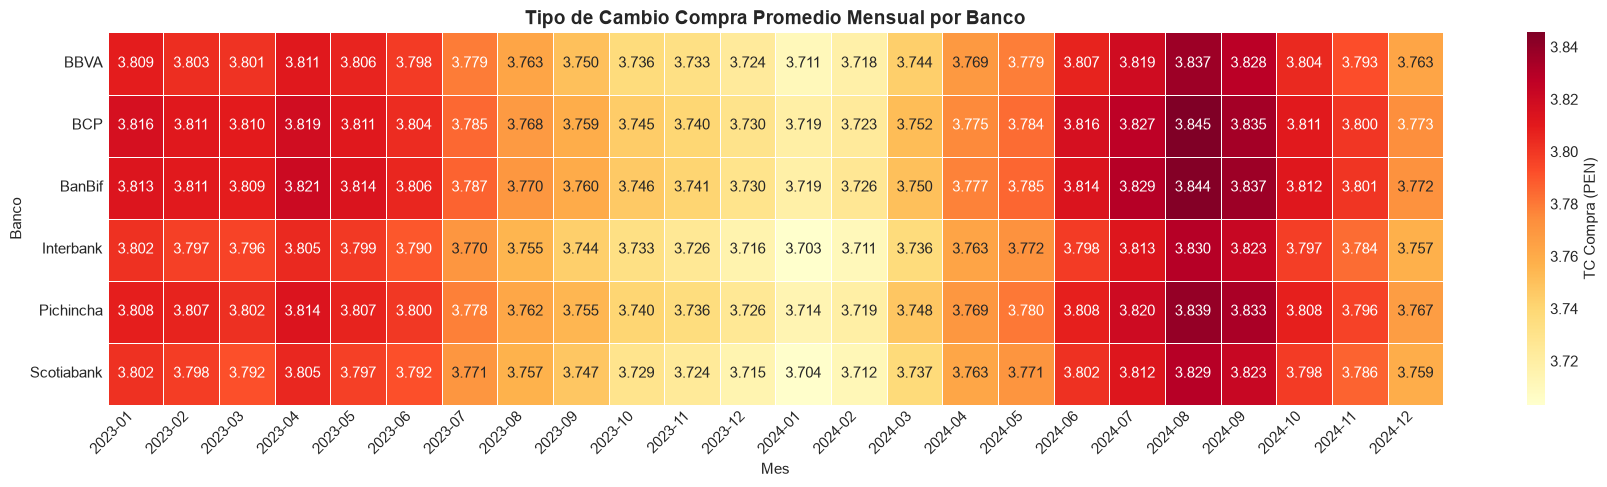

In [7]:
pivot_mensual = df.groupby(['banco', 'mes'])['tc_compra'].mean().unstack()
pivot_mensual.columns = [str(c) for c in pivot_mensual.columns]

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot_mensual, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'TC Compra (PEN)'})
ax.set_title('Tipo de Cambio Compra Promedio Mensual por Banco', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Banco')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## TC Compra por banco (interactivo)

In [8]:
semanal = df.groupby(['banco', pd.Grouper(key='fecha', freq='W')])['tc_compra'].mean().reset_index()

fig = px.line(semanal, x='fecha', y='tc_compra', color='banco',
              title='Tipo de Cambio Compra Semanal por Banco',
              labels={'tc_compra': 'TC Compra (PEN)', 'fecha': 'Fecha', 'banco': 'Banco'},
              color_discrete_sequence=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4'],
              template='plotly_white')
fig.update_layout(hovermode='x unified', legend=dict(orientation='h', y=-0.15))
fig.update_traces(line=dict(width=1.5))
fig.show()

## Spread promedio por banco (interactivo)

In [9]:
spread_promedio = df.groupby('banco')['spread'].mean().sort_values().reset_index()
spread_promedio.columns = ['banco', 'spread_promedio']

fig = px.bar(spread_promedio, x='banco', y='spread_promedio',
             color='spread_promedio',
             color_continuous_scale=['#44BBA4', '#F18F01', '#C73E1D'],
             title='Spread Promedio por Banco (Venta - Compra)',
             labels={'spread_promedio': 'Spread Promedio (PEN)', 'banco': 'Banco'},
             template='plotly_white')
fig.update_layout(showlegend=False)
fig.update_traces(texttemplate='%{y:.4f}', textposition='outside')
fig.show()

## Resumen estadístico por banco

In [10]:
resumen = df.groupby('banco').agg(
    tc_compra_min=('tc_compra', 'min'),
    tc_compra_max=('tc_compra', 'max'),
    tc_compra_media=('tc_compra', 'mean'),
    spread_media=('spread', 'mean'),
    spread_std=('spread', 'std'),
    registros=('tc_compra', 'count')
).round(4)
resumen.sort_values('spread_media')

,tc_compra_min,tc_compra_max,tc_compra_media,spread_media,spread_std,registros
banco,,,,,,
BCP,3.7062,3.8623,3.7857,0.0190,0.0023,522
Interbank,3.6955,3.8516,3.7716,0.0198,0.0023,522
BBVA,3.6930,3.8546,3.7785,0.0219,0.0023,522
Scotiabank,3.6944,3.8494,3.7718,0.0240,0.0023,522
BanBif,3.7081,3.8686,3.7864,0.0289,0.0023,522
Pichincha,3.7041,3.8603,3.7807,0.0320,0.0023,522
